In [2]:
library(tidyverse)
library(ape)
library(phytools)
library(phylolm)
library(tibble)
library(dplyr)
library(readr)
library(data.table)
library(gridExtra)
library(svglite)

### 1. Contributions to PCs

In [3]:
cichlid_tree = read.tree("Data/intree")

n_tips = length(cichlid_tree$tip.label)

n_branches = length(cichlid_tree$edge[, 1])

G <- matrix(0, nrow = n_branches, ncol = n_tips)
for (i in 1:n_branches) {
    node_needed = cichlid_tree$edge[i, 2]
    descendants = getDescendants(cichlid_tree, node_needed)
    descendants_needed = descendants[descendants <= n_tips]
    G[i, descendants_needed] = 1
}

In [4]:
sum_weights <- sum(cichlid_tree$edge.length)

C_N <- diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
branch <- G[1, ]
VCV_0 <- outer(branch, branch)
weight <- cichlid_tree$edge.length[1]
VCVs_vec <- as.vector(VCV_0) * weight
for (i in 2:n_branches) {
    branch <- G[i, ]
    VCV_0 <- outer(branch, branch)
    weight <- cichlid_tree$edge.length[i]
    VCVs_vec <- cbind(VCVs_vec, as.vector(VCV_0) * weight)
}

df <- as.data.frame(VCVs_vec)
colnames(df) <- paste0("VCV", 1:n_branches)

df$VCV_tot <- rowSums(df)
VCV_tot <- matrix(df$VCV_tot, nrow = n_tips, byrow = TRUE)

new_PCs = eigen(VCV_tot)$vectors

new_Sigma_names <- paste0("Sigma", 1:n_tips)
for (i in 1:n_tips) {
    new_Sigma = outer(new_PCs[,i], new_PCs[,i])
    name = new_Sigma_names[i]
    df[[name]] = as.vector(new_Sigma)
}

In [5]:
# Fit linear model
VCV_names_2 <- paste0("VCV", 2:n_branches)
str_formula <- paste(c("Sigma1 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_1 <- as.vector(coeffs)
# n_same_1 = which(is.na(branch_values_1))
# branch_values_1[1] <- branch_values_1[1] / 2
# branch_values_1[n_same_1] <- branch_values_1[1]

# Fit linear model
str_formula <- paste(c("Sigma10 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_2 <- as.vector(coeffs)
# n_same_2 = which(is.na(branch_values_2))
# branch_values_2[1] <- branch_values_2[1] / 2
# branch_values_2[n_same_2] <- branch_values_2[1]

# Fit linear model
str_formula <- paste(c("Sigma20 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_3 <- as.vector(coeffs)
# n_same_3 = which(is.na(branch_values_3))
# branch_values_3[1] <- branch_values_3[1] / 2
# branch_values_3[n_same_3] <- branch_values_3[1]

### 2. Phylogenetic Regressions

In [6]:
jaw_data = read.table("Data/CichlidX_TPM_GeneExpressionMatrix_LP.txt", 
                      header = TRUE, row.names = 1, sep = "\t", check.names = FALSE)

encoding_data = read.table("Data/GCF_001858045.1_ASM185804v2_genomic_gtf_gene.txt", 
                        header = TRUE, check.names = FALSE)

encoding_data <- encoding_data[encoding_data$biotype == "protein_coding",]
encoding_genes <- encoding_data$geneID

jaw_data <- jaw_data[!apply(jaw_data == 0, 1, any), ]

jaw_encoding_data <- jaw_data %>% filter(rownames(jaw_data) %in% encoding_genes)
jaw_encoding_genes = rownames(jaw_encoding_data)

log_jaw_encoding_data = log10(jaw_encoding_data)
names(log_jaw_encoding_data)[10] = "Calple"

In [7]:
# Randomly select 1000 pairs of genes with no replacement
n_pairs = 1000
counter = 0
n_genes = length(jaw_encoding_genes)

set.seed(23)

X_genes = sample(n_genes - 1, n_pairs)
gene_pairs = vector("list", n_pairs)
for (i in 1:n_pairs) {
    X_gene = X_genes[i]
    Y_gene = sample((X_gene + 1):n_genes, 1)
    gene_pairs[[i]] = c(X_gene, Y_gene)
}

In [8]:
PCs = eigen(vcv(cichlid_tree))$vectors
colnames(PCs) = paste0("PC_",1:ncol(PCs))
PCs = as_tibble(PCs)

num_PC = 20
PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
PC_sets = c("1",PC_sets)

n_rows = (1 + num_PC) * n_pairs

In [9]:
p_vals_PC = data.table(
    PCs = numeric(n_rows),
    p.value = numeric(n_rows),
    beta.hat = numeric(n_rows),
    aic = numeric(n_rows),
    X.gene = character(n_rows), 
    Y.gene = character(n_rows)
)

counter = 1
for (i in 1:n_pairs) {
    if (i %% 10 == 0) {message(i)}
    
    gene_pair = gene_pairs[[i]]
    X_gene = gene_pair[1]
    Y_gene = gene_pair[2]
    X = as.numeric(log_jaw_encoding_data[X_gene, ])
    Y = as.numeric(log_jaw_encoding_data[Y_gene, ])
    X_name = jaw_encoding_genes[X_gene]
    Y_name = jaw_encoding_genes[Y_gene]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y), PCs))
    
    rownames(all_data) = names(log_jaw_encoding_data)

    for (j in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
            suppressWarnings(cur_lm <- phylolm(cur_formula,data = all_data,phy = cichlid_tree))
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
            beta = summary(cur_lm)$coefficients["X","Estimate"]
            cur_aic = AIC(cur_lm)
            p_vals_PC[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                    "beta.hat" = beta, "aic" = cur_aic,
                                    "X.gene" = X_name, "Y.gene" = Y_name)]

            counter = counter + 1  
    }
}

10

20

30

40

50

60

70

80

90

100

110

120

130

140

150

160

170

180

190

200

210

220

230

240

250

260

270

280

290

300

310

320

330

340

350

360

370

380

390

400

410

420

430

440

450

460

470

480

490

500

510

520

530

540

550

560

570

580

590

600

610

620

630

640

650

660

670

680

690

700

710

720

730

740

750

760

770

780

790

800

810

820

830

840

850

860

870

880

890

900

910

920

930

940

950

960

970

980

990

1000



In [10]:
p_vals_PC_summary = p_vals_PC %>% group_by(PCs) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")

In [11]:
p_vals_qq_0 <- p_vals_PC %>% filter(PCs == 0)
p_vals_qq_5 <- p_vals_PC %>% filter(PCs == 5)
p_vals_qq_10 <- p_vals_PC %>% filter(PCs == 10)
p_vals_qq_14 <- p_vals_PC %>% filter(PCs == 14)
p_vals_qq_18 <- p_vals_PC %>% filter(PCs == 18)
p_vals_qq_20 <- p_vals_PC %>% filter(PCs == 20)

observed = c(sort(p_vals_qq_0$p.value), sort(p_vals_qq_5$p.value), 
             sort(p_vals_qq_10$p.value), sort(p_vals_qq_14$p.value), 
             sort(p_vals_qq_18$p.value), sort(p_vals_qq_20$p.value))
expected = rep(ppoints(n_pairs), 6)
method = rep(c("PGLS", "PGLS + 5 eigenvectors", 
               "PGLS + 10 eigenvectors", "PGLS + 14 eigenvectors", 
               "PGLS + 18 eigenvectors", "PGLS + 20 eigenvectors"), 
             each = n_pairs)

qq_plot_df <- data.frame(
    observed = -log10(observed), 
    expected = -log10(expected), 
    method = method
)
qq_plot_df$method = factor(qq_plot_df$method)

### 3. Plotting

In [12]:
# Create color mapping
n_colors <- 100
value_max_1 <- max(abs(branch_values_1))
value_max_2 <- max(abs(branch_values_2))
value_max_3 <- max(abs(branch_values_3))
color_breaks_1 <- seq(-value_max_1, value_max_1, length.out = n_colors + 1)
color_breaks_2 <- seq(-value_max_2, value_max_2, length.out = n_colors + 1)
color_breaks_3 <- seq(-value_max_3, value_max_3, length.out = n_colors + 1)

color_palette <- colorRampPalette(c("#364B9A", "#4A7BB7", "#6EA6CD", "#98CAE1", 
                                    "#C2E4EF", "#EAECCC", "#FEDA8B", "#FDB366", 
                                    "#F67E4B", "#DD3D2D", "#A50026"))(n_colors)

# Assign colors to branches based on where each value falls in the scale
branch_colors_1 <- color_palette[findInterval(branch_values_1, 
                                              color_breaks_1, 
                                              rightmost.closed = TRUE)]
branch_colors_2 <- color_palette[findInterval(branch_values_2, 
                                              color_breaks_2, 
                                              rightmost.closed = TRUE)]
branch_colors_3 <- color_palette[findInterval(branch_values_3, 
                                              color_breaks_3, 
                                              rightmost.closed = TRUE)]

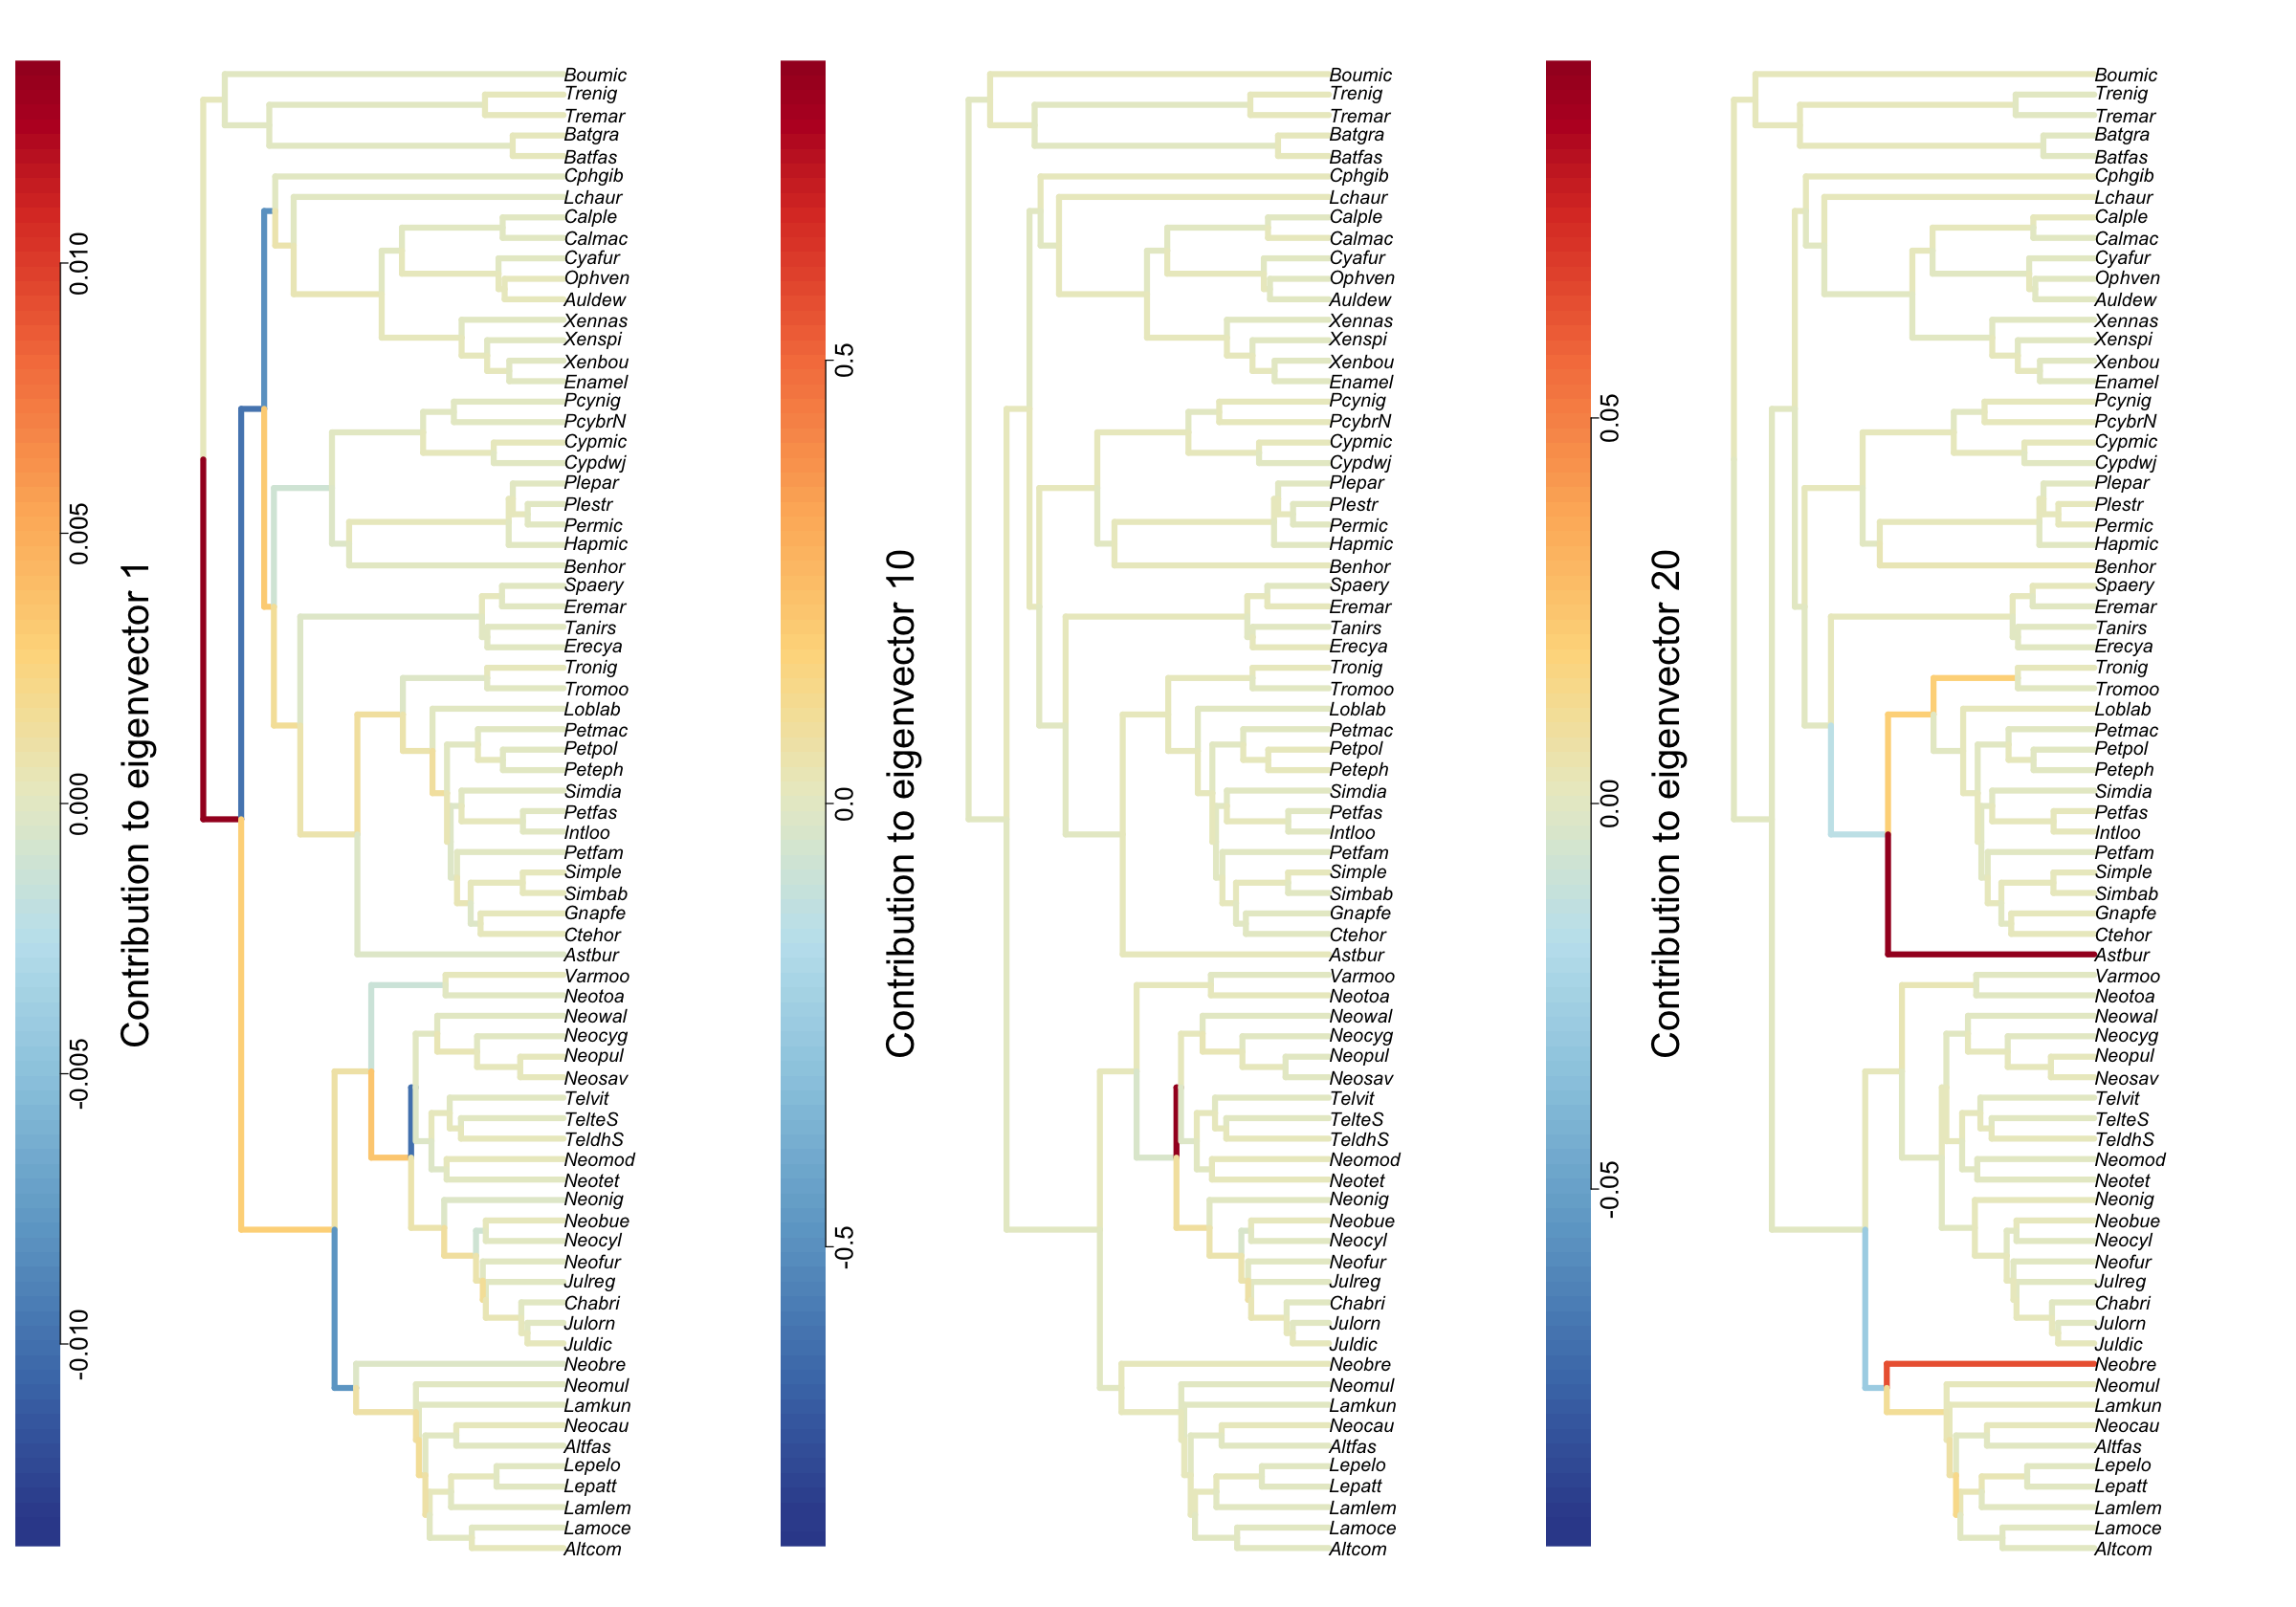

In [13]:
options(repr.plot.width = 20, repr.plot.height = 14)
layout(matrix(1:6, nrow = 1, byrow = TRUE), widths = c(3, 35, 3, 35, 3, 35))

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1, z = matrix(color_breaks_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 1", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_1, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2, z = matrix(color_breaks_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 10", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_2, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3, z = matrix(color_breaks_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 20", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_3, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

In [14]:
pdf("Figures_raw/chichlid_tree.pdf", width = 20, height = 14)

layout(matrix(1:6, nrow = 1, byrow = TRUE), widths = c(3, 35, 3, 35, 3, 35))

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1, z = matrix(color_breaks_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 1", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_1, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2, z = matrix(color_breaks_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 10", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_2, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3, z = matrix(color_breaks_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 20", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_3, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

dev.off()

pdf 
  2

In [15]:
svg("Figures_raw/chichlid_tree.svg", width = 20, height = 14)

layout(matrix(1:6, nrow = 1, byrow = TRUE), widths = c(3, 35, 3, 35, 3, 35))

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1, z = matrix(color_breaks_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 1", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_1, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2, z = matrix(color_breaks_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 10", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_2, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3, z = matrix(color_breaks_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 20", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_3, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

dev.off()

pdf 
  2

Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2 3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”


TableGrob (1 x 1) "arrange": 1 grobs
  z     cells    name            grob
1 1 (1-1,1-1) arrange gtable[arrange]

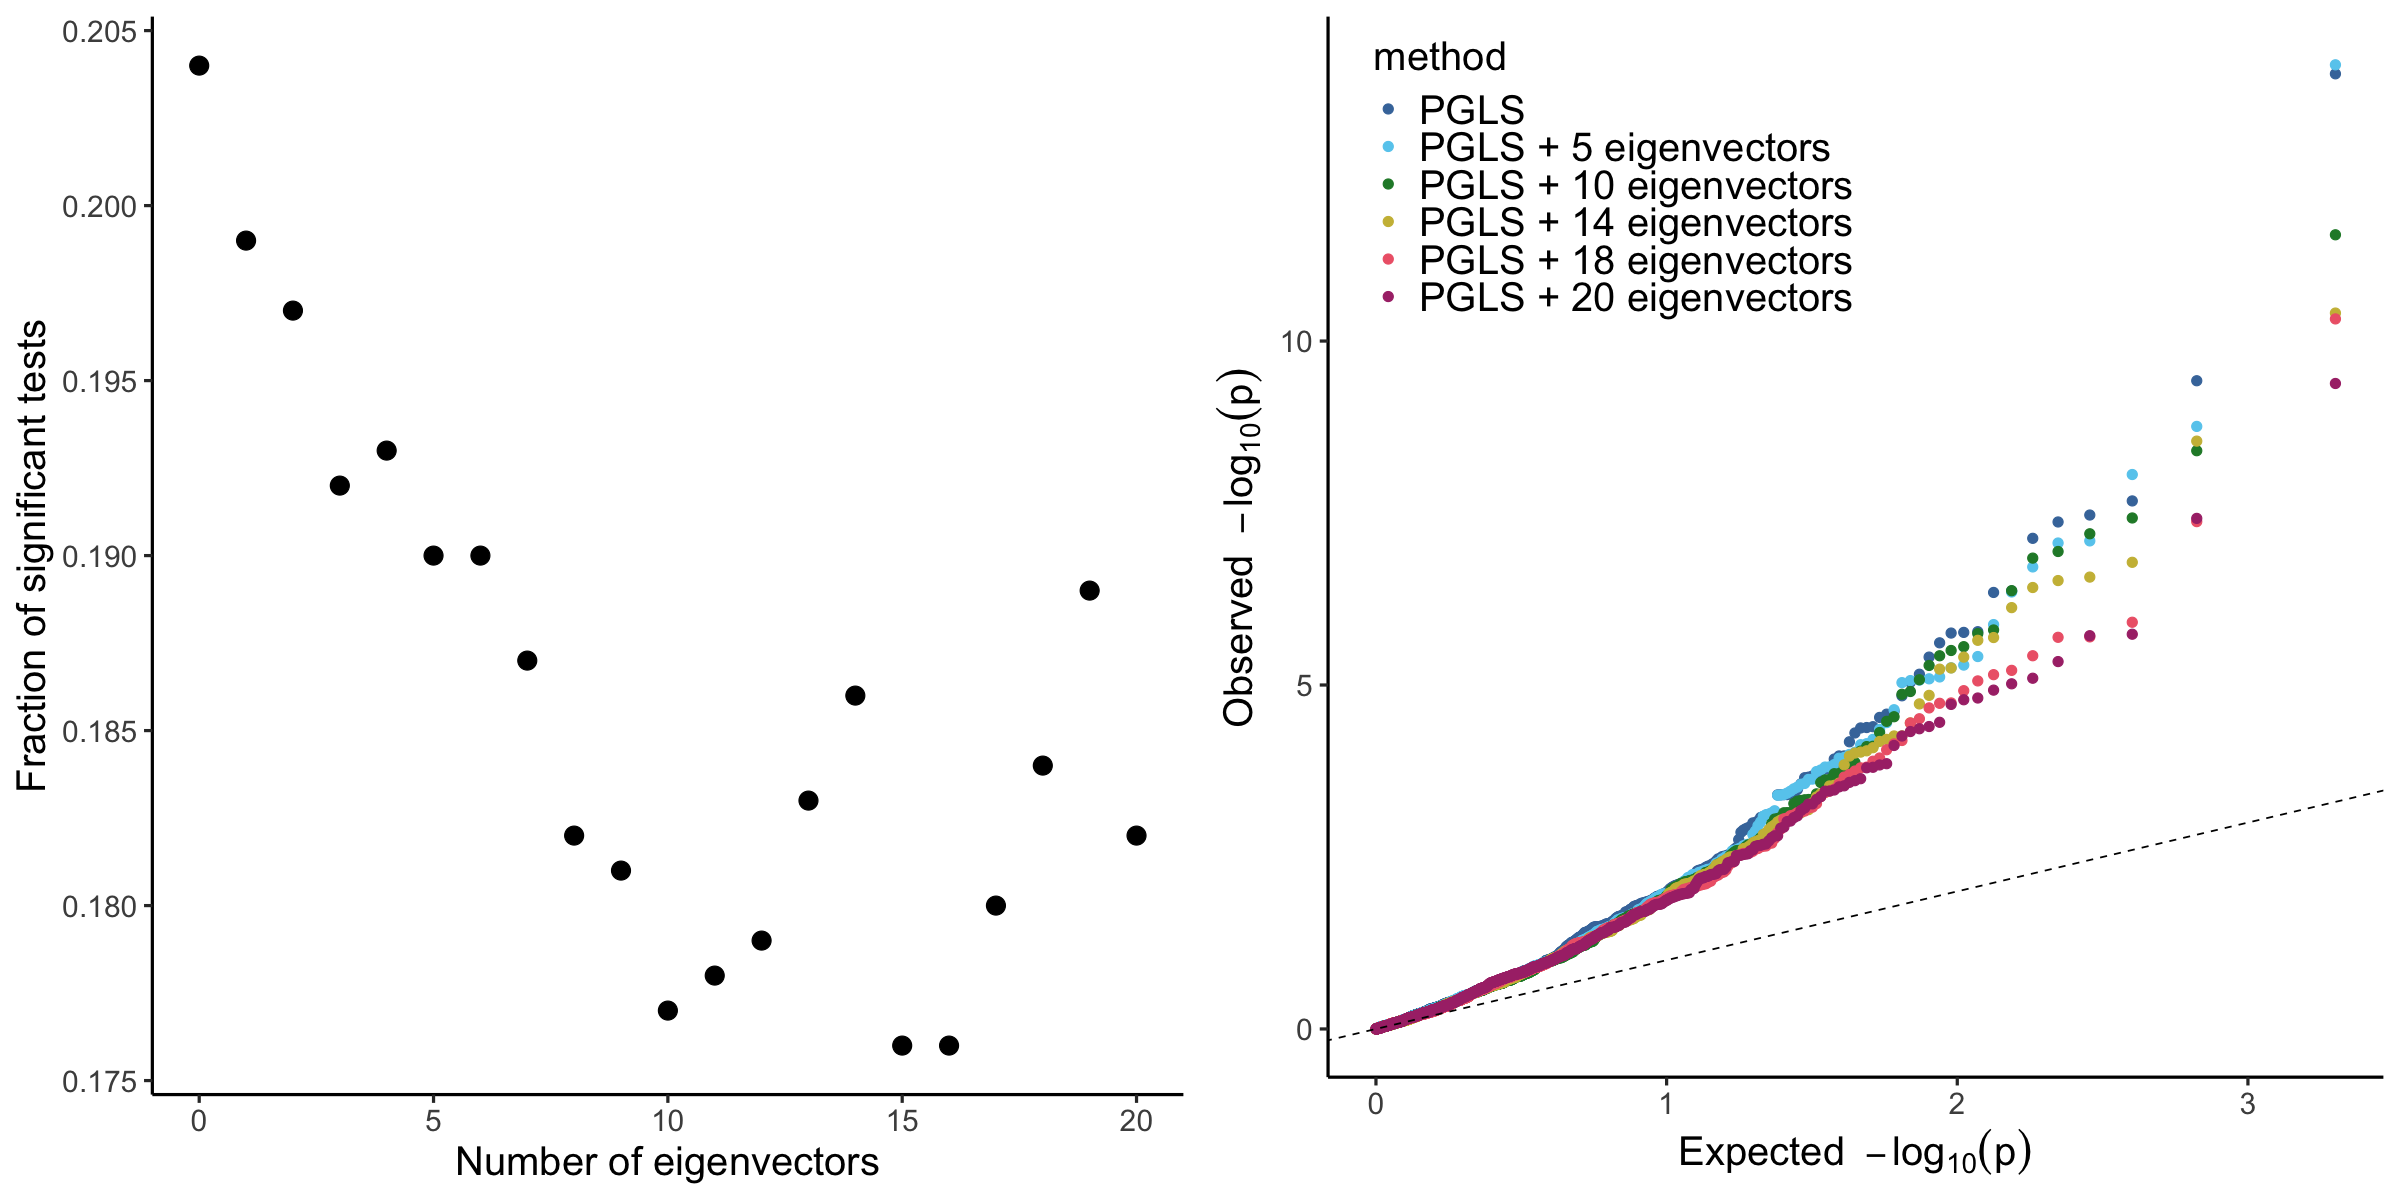

In [16]:
plot_pgls <- ggplot() +
  geom_point(data = p_vals_PC_summary, aes(PCs, FPR), size = 5) +
  theme_classic(base_size=20) +
  theme(axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
  xlab("Number of eigenvectors") +
  ylab("Fraction of significant tests") + 
  theme(legend.position=c(.22,.7),legend.spacing.y = unit(1,"pt"), 
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 24))

par(mar = c(1, 1, 1, 1))
qq_plot <- qq_plot_df %>% ggplot(aes(expected, observed, color = method)) +
  geom_point(size = 2.5) + 
  theme_classic(base_size=20) +
  xlab(expression(Expected~~-log[10](p))) +
  ylab(expression(Observed~~-log[10](p))) +
  theme(legend.position=c(.27,.85),legend.spacing.y = unit(1,"pt"), 
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
  scale_color_manual(values=c("#4477AA","#66CCEE","#228833","#CCBB44", "#EE6677", "#AA3377"), 
                     breaks = c("PGLS", "PGLS + 5 eigenvectors", 
                                "PGLS + 10 eigenvectors", "PGLS + 14 eigenvectors",
                                "PGLS + 18 eigenvectors", "PGLS + 20 eigenvectors")) + 
  geom_abline(slope = 1, intercept = 0,lty = 2)


options(repr.plot.width = 20, repr.plot.height = 10)

row <- arrangeGrob(plot_pgls, qq_plot, ncol = 2)

g <- grid.arrange(row, nrow = 1)
g
# ggsave("Figures_raw/chichlid_PGLS.pdf", g, width = 20, height = 10)
# ggsave("Figures_raw/chichlid_PGLS.svg", g, width = 20, height = 10)

### 4. Additional Analyses

#### 4.1. Using indicators in PGLS

In [17]:
sum_branch_lengths <- sum(cichlid_tree$edge.length)

cov_matrices <- matrix(0, nrow = n_tips^2, ncol = n_branches + 1)
# calculate the weighted variance-covariance matrix for each branch
for (i in 1:n_branches) {
    branch <- G[i, ]
    weight <- cichlid_tree$edge.length[i]
    cov_matrix_branch <- outer(branch, branch) * weight
    cov_matrices[, i] <- as.vector(cov_matrix_branch)
}

# calculate the variance-covariance matrix for the whole tree
cov_matrices[, n_branches + 1] <- rowSums(cov_matrices)
cov_matrix_total <- matrix(cov_matrices[, n_branches + 1], nrow = n_tips, 
                           byrow = TRUE)

# wrap the computations in a data frame
cov_matrices <- as.data.frame(cov_matrices)
colnames(cov_matrices) <- c(paste0("vcv_", 1:n_branches), "vcv_tot")

# get the names for the covariance matrices for each branch
cov_matrices_names <- colnames(cov_matrices)
cov_matrices_names <- cov_matrices_names[-(n_branches + 1)]

# calculate eigenvectors for the covariance matrix of the tree
vs <- eigen(cov_matrix_total)$vectors
lambdas <- eigen(cov_matrix_total)$values

for (i in 1:n_tips) {
    matrix_name <- paste0("eigen_", i)
    cov_matrices[[matrix_name]] <- as.vector(outer(vs[, i], vs[, i]))
}

# initialize the branch contributions matrix
branch_contributions <- matrix(0, nrow = n_branches, ncol = n_tips)

# create the common part of the formula for regression in string format
str_formula_common <- paste(cov_matrices_names, collapse = " + ")
str_formula_common <- paste("~", str_formula_common, "- 1")

# calculate the branch contributions to each of the dimensions
for (i in 1:n_tips) {
    # complete the formula for regression in string format
    eigen_name <- paste0("eigen_", i)
    str_formula <- paste(eigen_name, str_formula_common)
    reg_formula <- as.formula(str_formula)

    # run the regression
    model <- lm(reg_formula, data = cov_matrices)
    coeffs <- as.vector(coef(model))
    branch_contributions[, i] <- coeffs
}

# wrap the branch contributions in a data frame
branch_contributions <- as.data.frame(branch_contributions)
colnames(branch_contributions) <- paste0("dim_", 1:n_tips)

l2_sum_dim <- sqrt((as.matrix(branch_contributions)^2) %*% lambdas)

In [18]:
branch_order <- order(l2_sum_dim, decreasing = TRUE)
branch_order[1:20]

[1]  92 127  29  45  70  39  35  41  27  95  67 112  44   7 104 103   6  40  77
[20] 120

In [19]:
G_update = t(G)
# rownames(G_update) = cichlid_tree$tip.label
colnames(G_update) = paste0("branch_", 1:n_branches)
G_update = as_tibble(G_update)
G_update

branch_1,branch_2,branch_3,branch_4,branch_5,branch_6,branch_7,branch_8,branch_9,branch_10,⋯,branch_135,branch_136,branch_137,branch_138,branch_139,branch_140,branch_141,branch_142,branch_143,branch_144
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1,1,1,1,1,1,1,0,⋯,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,1,1,1,0,1,⋯,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,1,1,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,1,1,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,1,1,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [20]:
num_ind = 20
ind_sets = lapply(1:num_ind, function(i){paste0("branch_", branch_order[1:i])})
ind_sets = c("1", ind_sets)

In [21]:
p_vals_ind = data.table(
    ind = numeric(n_rows),
    p.value = numeric(n_rows), 
    beta.hat = numeric(n_rows),
    aic = numeric(n_rows),
    X.gene = character(n_rows), 
    Y.gene = character(n_rows)
)

counter = 1
for (i in 1:n_pairs) {
    if (i %% 10 == 0) {message(i)}
    
    gene_pair = gene_pairs[[i]]
    X_gene = gene_pair[1]
    Y_gene = gene_pair[2]
    X = as.numeric(log_jaw_encoding_data[X_gene, ])
    Y = as.numeric(log_jaw_encoding_data[Y_gene, ])
    X_name = jaw_encoding_genes[X_gene]
    Y_name = jaw_encoding_genes[Y_gene]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y), G_update))
    
    rownames(all_data) = names(log_jaw_encoding_data)

    for (j in 1:length(ind_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", ind_sets[[j]]),collapse=" + "))
        
        tryCatch({
            suppressWarnings(cur_lm <- phylolm(cur_formula,data=all_data,phy=cichlid_tree))
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
            beta = summary(cur_lm)$coefficients["X","Estimate"]
            cur_aic = AIC(cur_lm)
            p_vals_ind[counter, `:=`("ind" = j - 1, "p.value" = cur_p,
                                     "beta.hat" = beta, "aic" = cur_aic,
                                     "X.gene" = X_name, "Y.gene" = Y_name)]
        }, error = function(e) { 
            p_vals_ind[counter, `:=`("ind" = j - 1, "p.value" = NA,  
                                     "beta.hat" = NA, "aic" = NA,
                                     "X.gene" = X_name, "Y.gene" = Y_name)]
        })            
        counter = counter + 1  
    }
}

10

20

30

40

50

60

70

80

90

100

110

120

130

140

150

160

170

180

190

200

210

220

230

240

250

260

270

280

290

300

310

320

330

340

350

360

370

380

390

400

410

420

430

440

450

460

470

480

490

500

510

520

530

540

550

560

570

580

590

600

610

620

630

640

650

660

670

680

690

700

710

720

730

740

750

760

770

780

790

800

810

820

830

840

850

860

870

880

890

900

910

920

930

940

950

960

970

980

990

1000



In [22]:
p_vals_ind_summary = p_vals_ind %>% group_by(ind) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")

In [23]:
p_vals_qq_0 <- p_vals_ind %>% filter(ind == 0)
p_vals_qq_5 <- p_vals_ind %>% filter(ind == 5)
p_vals_qq_10 <- p_vals_ind %>% filter(ind == 10)
p_vals_qq_15 <- p_vals_ind %>% filter(ind == 15)

observed = c(sort(p_vals_qq_0$p.value), sort(p_vals_qq_5$p.value), 
             sort(p_vals_qq_10$p.value), sort(p_vals_qq_15$p.value))
expected = rep(ppoints(n_pairs), 4)
method = rep(c("PGLS", "PGLS + 5 indicators", 
               "PGLS + 10 indicators", "PGLS + 15 indicators"), 
             each = n_pairs)

qq_plot_df <- data.frame(
    observed = -log10(observed), 
    expected = -log10(expected), 
    method = method
)
qq_plot_df$method = factor(qq_plot_df$method)

Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_point()`).”


TableGrob (1 x 1) "arrange": 1 grobs
  z     cells    name            grob
1 1 (1-1,1-1) arrange gtable[arrange]

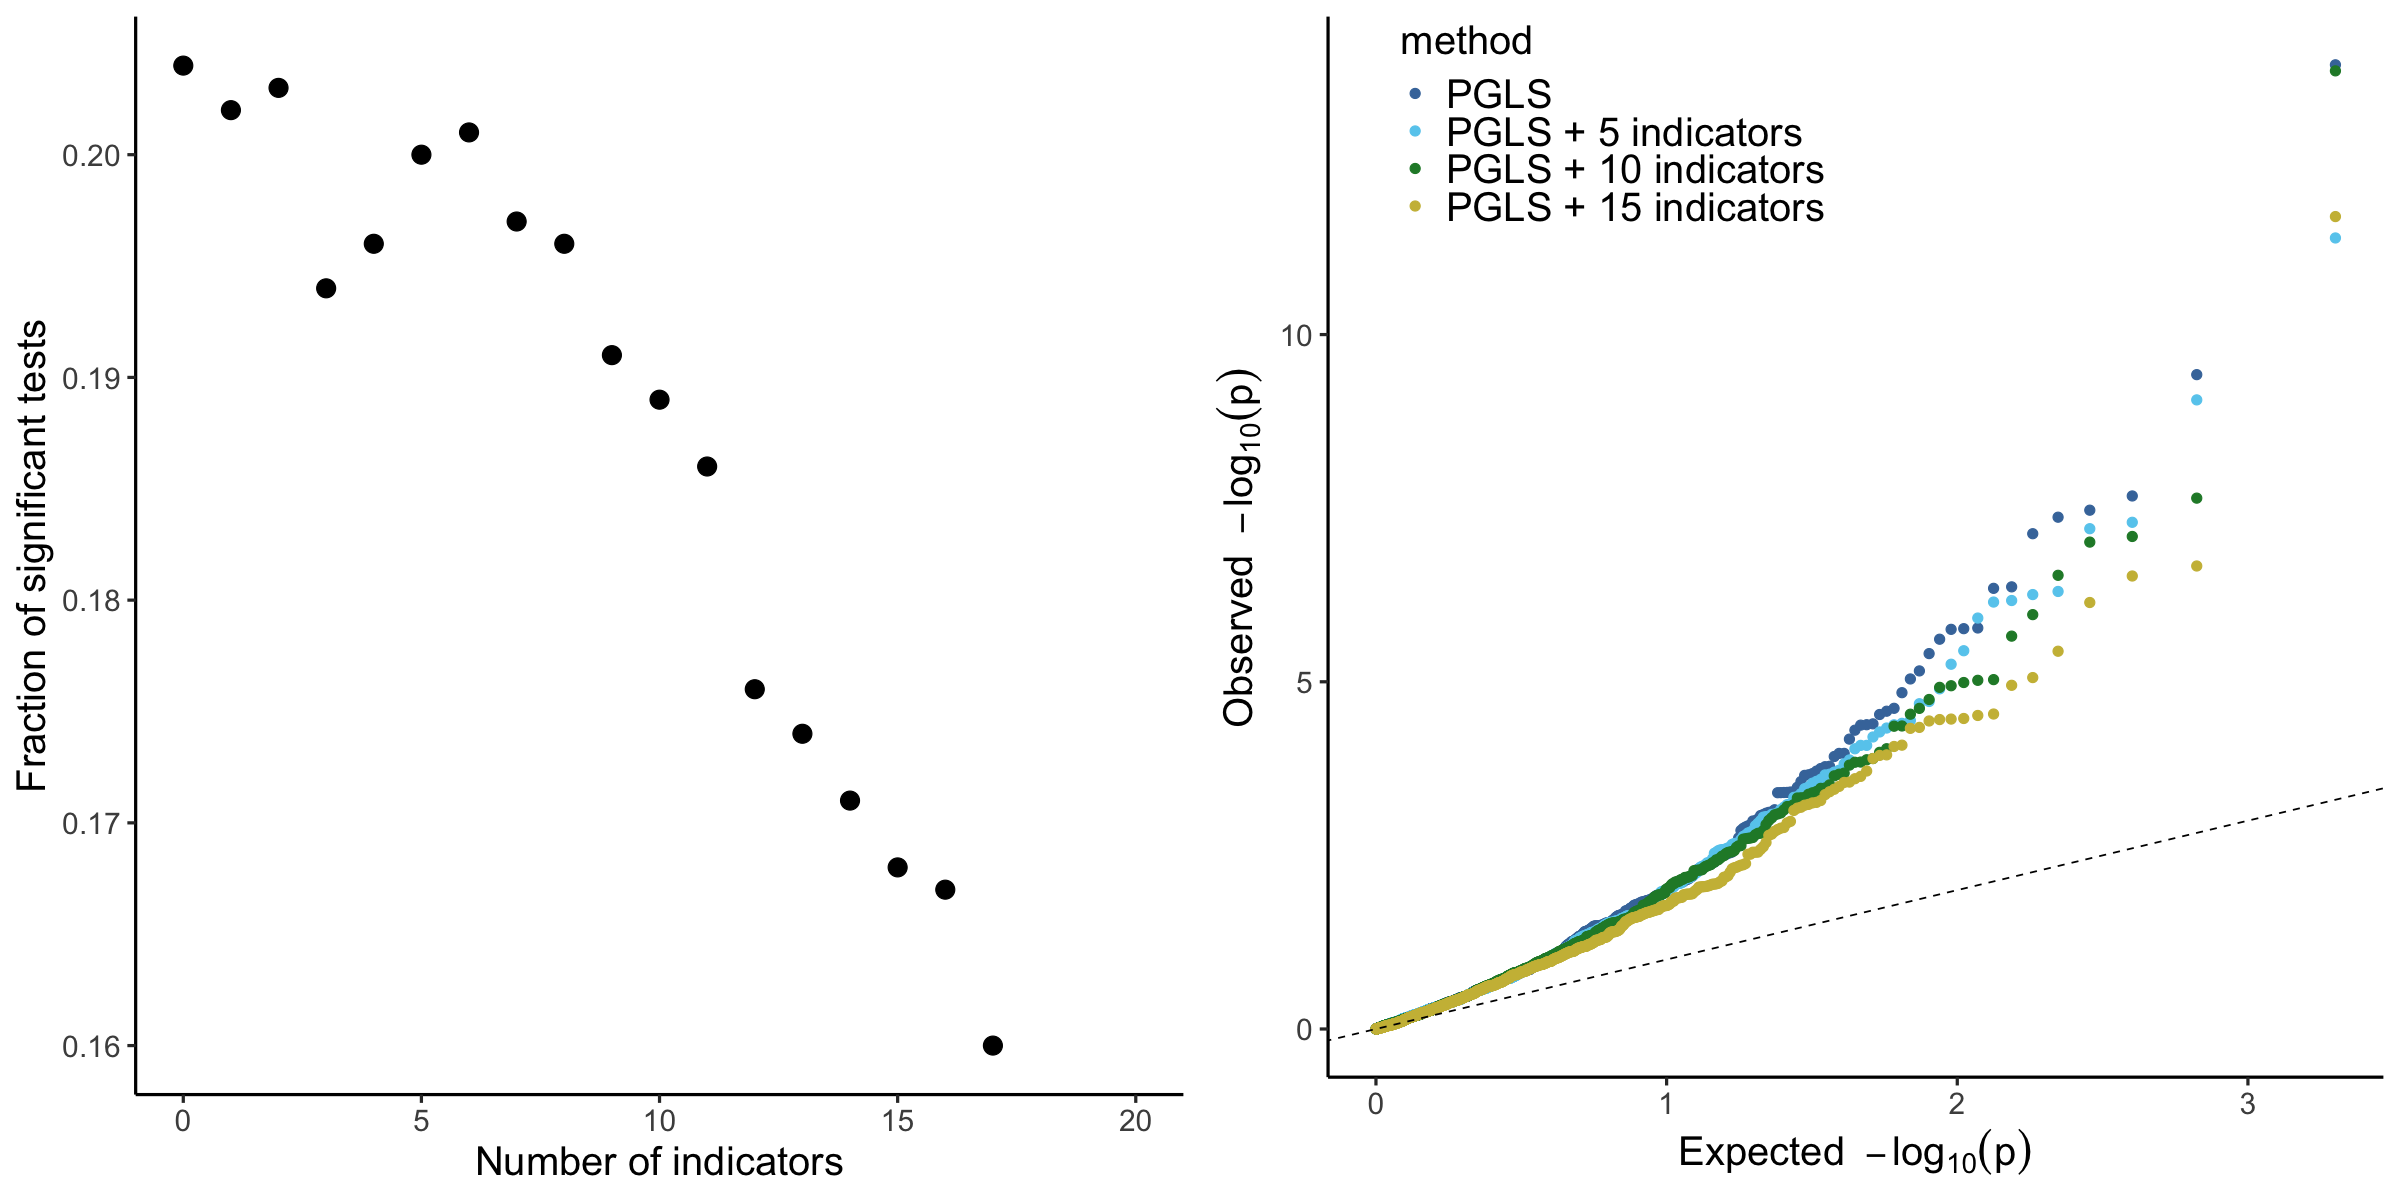

In [24]:
plot_pgls <- ggplot() +
  geom_point(data = p_vals_ind_summary, aes(ind, FPR), size = 5) +
  theme_classic(base_size=20) +
  theme(axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
  xlab("Number of indicators") +
  ylab("Fraction of significant tests") + 
  theme(legend.position=c(.22,.7),legend.spacing.y = unit(1,"pt"), 
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 24))

qq_plot <- qq_plot_df %>% ggplot(aes(expected, observed, color = method)) +
  geom_point(size = 2.5) + 
  theme_classic(base_size=20) +
  xlab(expression(Expected~~-log[10](p))) +
  ylab(expression(Observed~~-log[10](p))) +
  theme(legend.position=c(.27,.9),legend.spacing.y = unit(1,"pt"), 
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
  scale_color_manual(values=c("#4477AA","#66CCEE","#228833","#CCBB44"), 
                     breaks = c("PGLS", "PGLS + 5 indicators", "PGLS + 10 indicators", "PGLS + 15 indicators")) + 
  geom_abline(slope = 1, intercept = 0,lty = 2)


options(repr.plot.width = 20, repr.plot.height = 10)

row <- arrangeGrob(plot_pgls, qq_plot, ncol = 2)

# Arrange all rows into one layout
g <- grid.arrange(row, nrow = 1)
g
# ggsave("Figures_raw/chichlid_PGLS.pdf", g, width = 20, height = 10)
# ggsave("Figures_raw/chichlid_PGLS.svg", g, width = 20, height = 10)

#### 4.2. Analyses by bins for beta

In [25]:
p_vals_PC$beta.hat.abs.round = 2 ^ round(log2(abs(p_vals_PC$beta.hat)))

In [26]:
p_vals_PC_summary_1 = p_vals_PC %>% 
  mutate(
    beta = case_when(
      beta.hat.abs.round <= 0.0625 ~ "<=0.0625",
      beta.hat.abs.round == 0.125 ~ "0.125",
      beta.hat.abs.round == 0.25 ~ "0.25",
      beta.hat.abs.round == 0.5 ~ "0.5",
      beta.hat.abs.round >= 1 ~ ">=1",
    )
  ) %>% 
  group_by(PCs, beta) %>%
  summarise(FPR = mean(p.value<0.05), n = n(), .groups = "drop")

p_vals_PC_summary_1$beta <- factor(p_vals_PC_summary_1$beta,
                                 levels = c("<=0.0625", "0.125", "0.25", "0.5", ">=1"))

In [27]:
PC_plot <- p_vals_PC_summary_1 %>% ggplot(aes(PCs, FPR, color = beta)) +
  geom_point(size = 2.5) + 
  theme_classic(base_size=20) +
  xlab("Number of eigenvectors") +
  ylab("Fraction of significant tests") +
  theme(legend.position="right",legend.spacing.y = unit(1,"pt"), 
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
  scale_color_manual(values=c("#4477AA","#66CCEE","#228833","#CCBB44", "#EE6677"), 
                     breaks = c("<=0.0625", "0.125", "0.25", "0.5", ">=1"),
                     labels = c(expression("(" * -infinity * "," * -3.5 * ")"), 
                                expression("[" * -3.5 * "," * -2.5 * ")"), 
                                expression("[" * -2.5 * "," * -1.5 * ")"), 
                                expression("[" * -1.5 * "," * -0.5 * ")"), 
                                expression("[" * -0.5 * "," * infinity * ")"))) +
  labs(color = expression(log[2](abs(hat(beta)))))

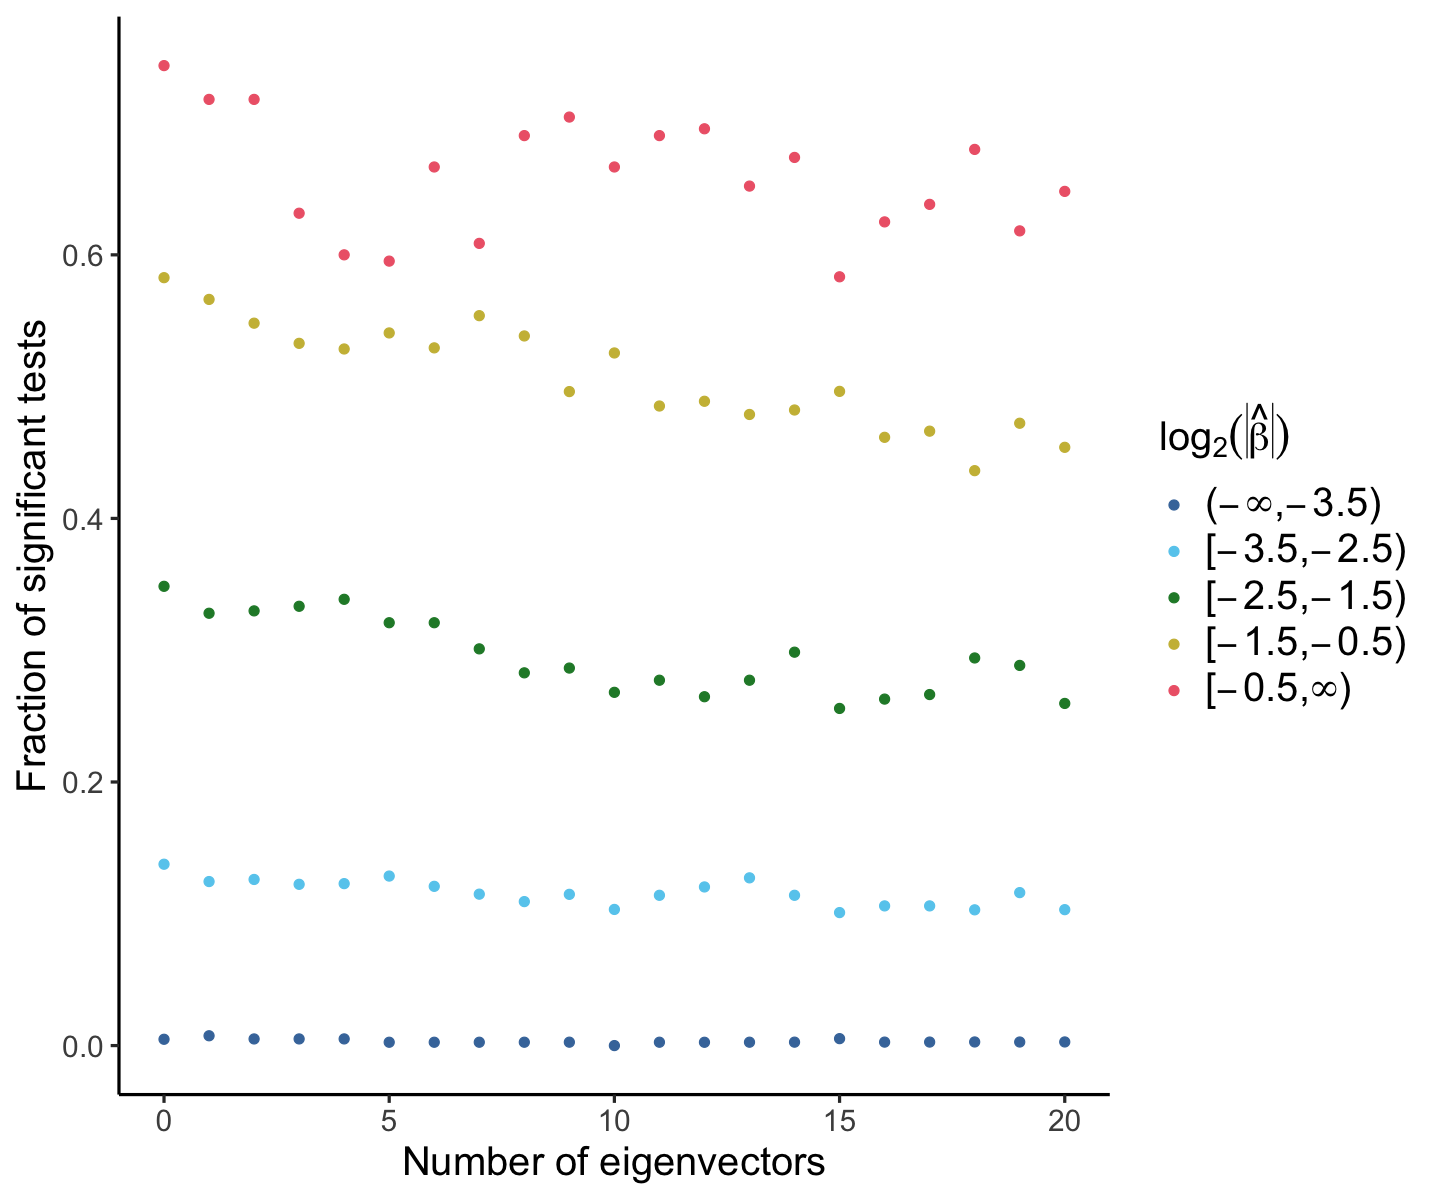

In [28]:
options(repr.plot.width = 12, repr.plot.height = 10)
PC_plot

ggsave("Figures_raw/chichlid_P.pdf", PC_plot, width = 12, height = 10)
ggsave("Figures_raw/chichlid_P.svg", PC_plot, width = 12, height = 10)

In [29]:
beta_plot <- p_vals_PC_summary_1 %>% ggplot(aes(x = PCs, y = n, fill = beta)) +
  geom_col(linewidth = 2) +
  theme_classic(base_size=20) +
  xlab("Number of eigenvectors") +
  ylab("Number of tests") +
  theme(legend.position="right",legend.spacing.y = unit(1,"pt"), 
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
  scale_fill_manual(values=c("#4477AA","#66CCEE","#228833","#CCBB44", "#EE6677"), 
                    breaks = c("<=0.0625", "0.125", "0.25", "0.5", ">=1"),
                    labels = c(expression("(" * -infinity * "," * -3.5 * ")"), 
                               expression("[" * -3.5 * "," * -2.5 * ")"), 
                               expression("[" * -2.5 * "," * -1.5 * ")"), 
                               expression("[" * -1.5 * "," * -0.5 * ")"), 
                               expression("[" * -0.5 * "," * infinity * ")"))) +
  labs(fill = expression(log[2](abs(hat(beta)))))

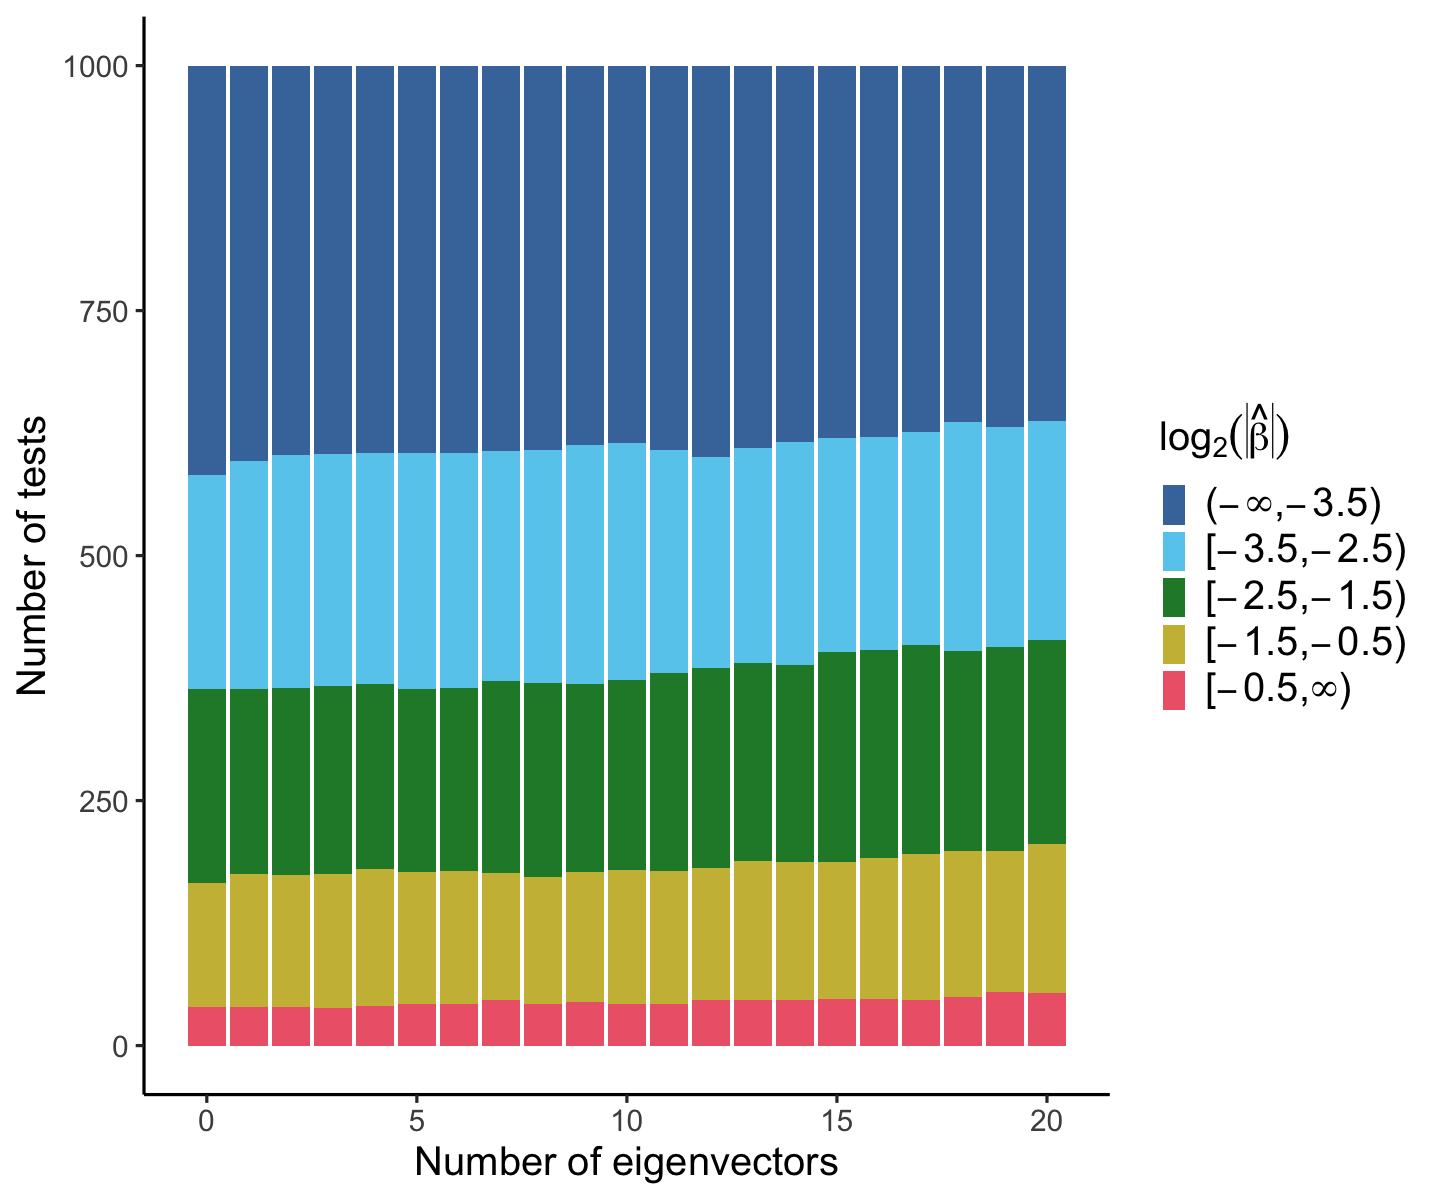

In [30]:
options(repr.plot.width = 12, repr.plot.height = 10)
beta_plot

#ggsave("Figures_raw/chichlid_beta.pdf", beta_plot, width = 12, height = 10)
#ggsave("Figures_raw/chichlid_beta.svg", beta_plot, width = 12, height = 10)